<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/AAP_CHAP_4_I_Supercharged_IoT_Ecosystem_for_Sustainable_Agricultural_Data_Streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Generating a Synthetic Agricultural IoT Sensor Dataset

I will create a synthetic dataset using `pandas` to simulate sensor readings from an IoT ecosystem in agriculture. This dataset will include `timestamp`, `farm_id`, `crop_type`, `soil_moisture`, `air_temperature`, `humidity`, and `ph_level` to represent typical data streamed from agricultural sensors.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Define the date range for the simulated data
start_date = pd.to_datetime('2023-01-01')
end_date = pd.to_datetime('2023-01-31')
num_days = (end_date - start_date).days + 1

# Generate timestamps, assuming hourly readings for 3 farms
timestamps = pd.date_range(start=start_date, end=end_date, freq='h') # Changed 'H' to 'h'

# Define farm and crop types
farm_ids = ['Farm_A', 'Farm_B', 'Farm_C']
crop_types = ['Wheat', 'Corn', 'Soybeans']

# Create an empty list to store data for each record
data = []

for ts in timestamps:
    for farm_id in farm_ids:
        # Assign a specific crop type to each farm for simplicity, or randomize
        if farm_id == 'Farm_A': crop = 'Wheat'
        elif farm_id == 'Farm_B': crop = 'Corn'
        else: crop = 'Soybeans'

        # Simulate sensor readings with some variation and trend
        # Soil Moisture: varies between 20-80%
        soil_moisture = np.random.normal(50, 10) + 5 * np.sin(ts.dayofyear / 365 * 2 * np.pi)
        soil_moisture = np.clip(soil_moisture, 20, 80) # Clip to realistic range

        # Air Temperature: varies between 15-35°C
        air_temperature = np.random.normal(25, 5) + 3 * np.sin(ts.hour / 24 * 2 * np.pi)
        air_temperature = np.clip(air_temperature, 15, 35)

        # Humidity: varies between 40-90%
        humidity = np.random.normal(70, 10) + 5 * np.cos(ts.hour / 24 * 2 * np.pi)
        humidity = np.clip(humidity, 40, 90)

        # pH Level: varies between 5.5-7.5
        ph_level = np.random.normal(6.5, 0.5)
        ph_level = np.clip(ph_level, 5.5, 7.5)

        data.append({
            'timestamp': ts,
            'farm_id': farm_id,
            'crop_type': crop,
            'soil_moisture': soil_moisture,
            'air_temperature': air_temperature,
            'humidity': humidity,
            'ph_level': ph_level
        })

# Create the DataFrame
df = pd.DataFrame(data)

# Display the first 5 rows of the dataset
print("Synthetic Agricultural IoT Dataset Head:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
display(df.info())

Synthetic Agricultural IoT Dataset Head:


,timestamp,farm_id,crop_type,soil_moisture,air_temperature,humidity,ph_level
0,2023-01-01 00:00:00,Farm_A,Wheat,55.053208,24.308678,81.476885,7.261515
1,2023-01-01 00:00:00,Farm_B,Corn,47.744533,23.829315,90.000000,6.883717
2,2023-01-01 00:00:00,Farm_C,Soybeans,45.391323,27.712800,70.365823,6.267135
3,2023-01-01 01:00:00,Farm_A,Wheat,52.505689,16.210056,57.580451,6.218856
4,2023-01-01 01:00:00,Farm_B,Corn,39.957756,27.347694,65.749388,5.793848



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163 entries, 0 to 2162
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        2163 non-null   datetime64[ns]
 1   farm_id          2163 non-null   object        
 2   crop_type        2163 non-null   object        
 3   soil_moisture    2163 non-null   float64       
 4   air_temperature  2163 non-null   float64       
 5   humidity         2163 non-null   float64       
 6   ph_level         2163 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 118.4+ KB


None

## Visualizing Insights from the Agricultural IoT Data

Now, let's visualize some key aspects of this synthetic dataset to understand potential patterns and insights, as would be common in an AI-supercharged IoT ecosystem for agriculture.

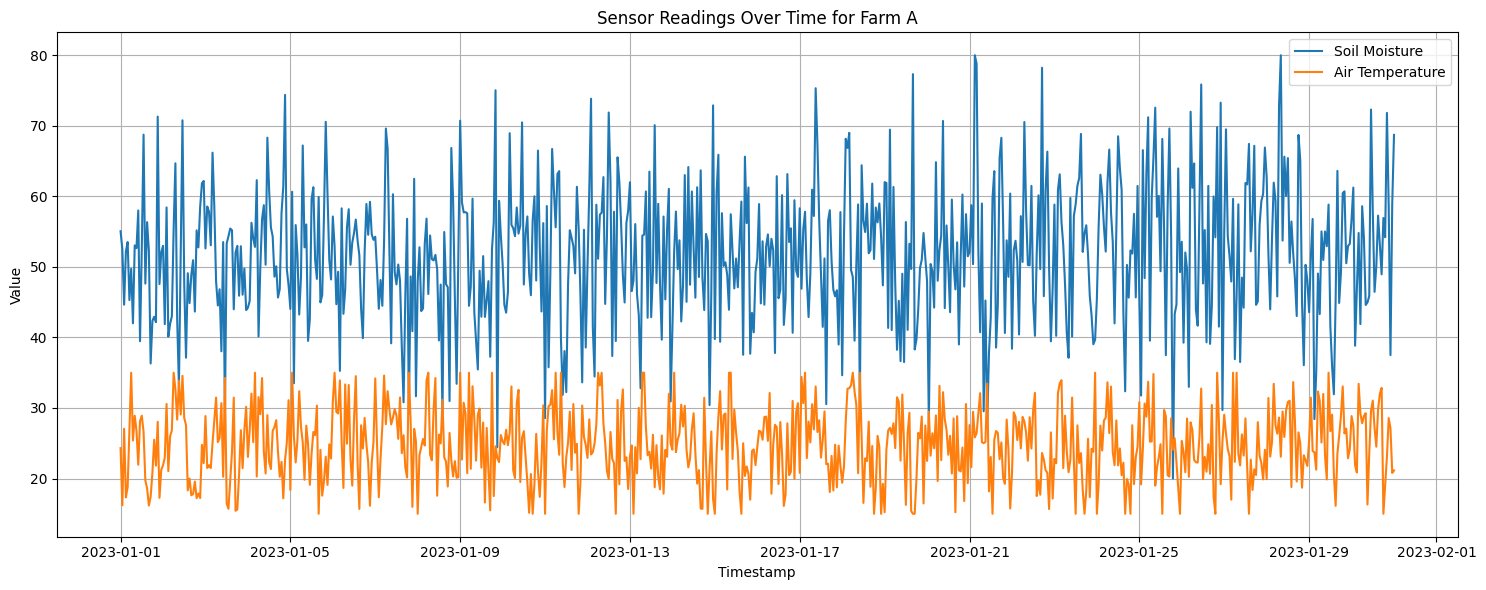

In [2]:
# 1. Time-series plot of sensor readings for a specific farm
plt.figure(figsize=(15, 6))
sns.lineplot(data=df[df['farm_id'] == 'Farm_A'], x='timestamp', y='soil_moisture', label='Soil Moisture')
sns.lineplot(data=df[df['farm_id'] == 'Farm_A'], x='timestamp', y='air_temperature', label='Air Temperature')
plt.title('Sensor Readings Over Time for Farm A')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

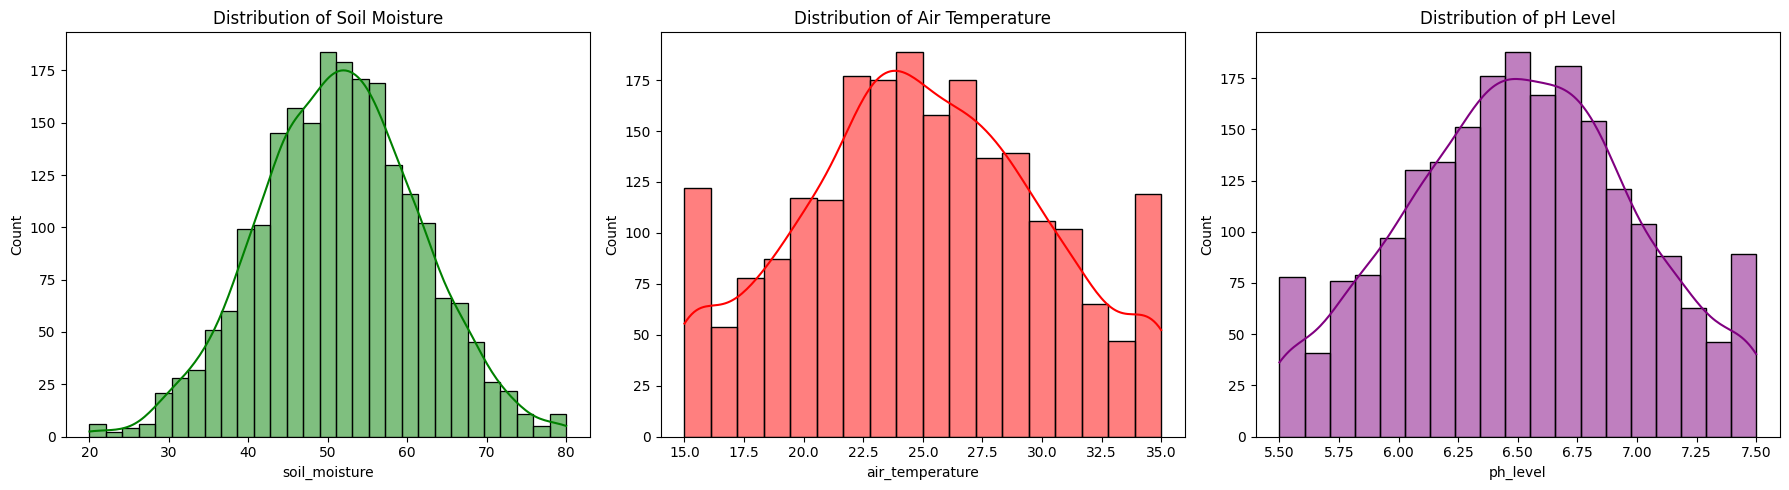

In [3]:
# 2. Distribution of key sensor readings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['soil_moisture'], kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribution of Soil Moisture')

sns.histplot(df['air_temperature'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Air Temperature')

sns.histplot(df['ph_level'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Distribution of pH Level')

plt.tight_layout()
plt.show()

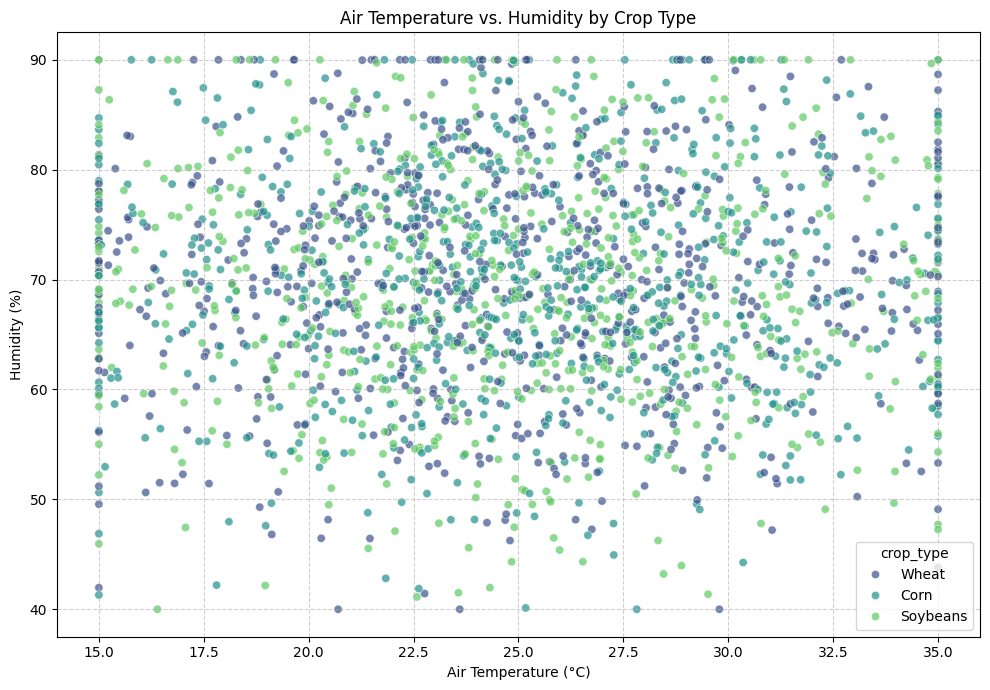

In [4]:
# 3. Relationship between Air Temperature and Humidity, colored by Crop Type
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='air_temperature', y='humidity', hue='crop_type', palette='viridis', alpha=0.7)
plt.title('Air Temperature vs. Humidity by Crop Type')
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

These visualizations provide a basic overview of the simulated agricultural IoT data. An 'AI-Supercharged' system would use similar data to build predictive models for crop health, irrigation needs, disease detection, and yield optimization, thereby contributing to sustainable agriculture.

## Further Visualizations: Comparing Sensor Readings Across Farms and Crop Types

Let's use box plots to compare the distributions of sensor readings (soil moisture, air temperature, humidity, pH level) across different farms and crop types. This can highlight if certain farms or crop types experience systematically different environmental conditions.

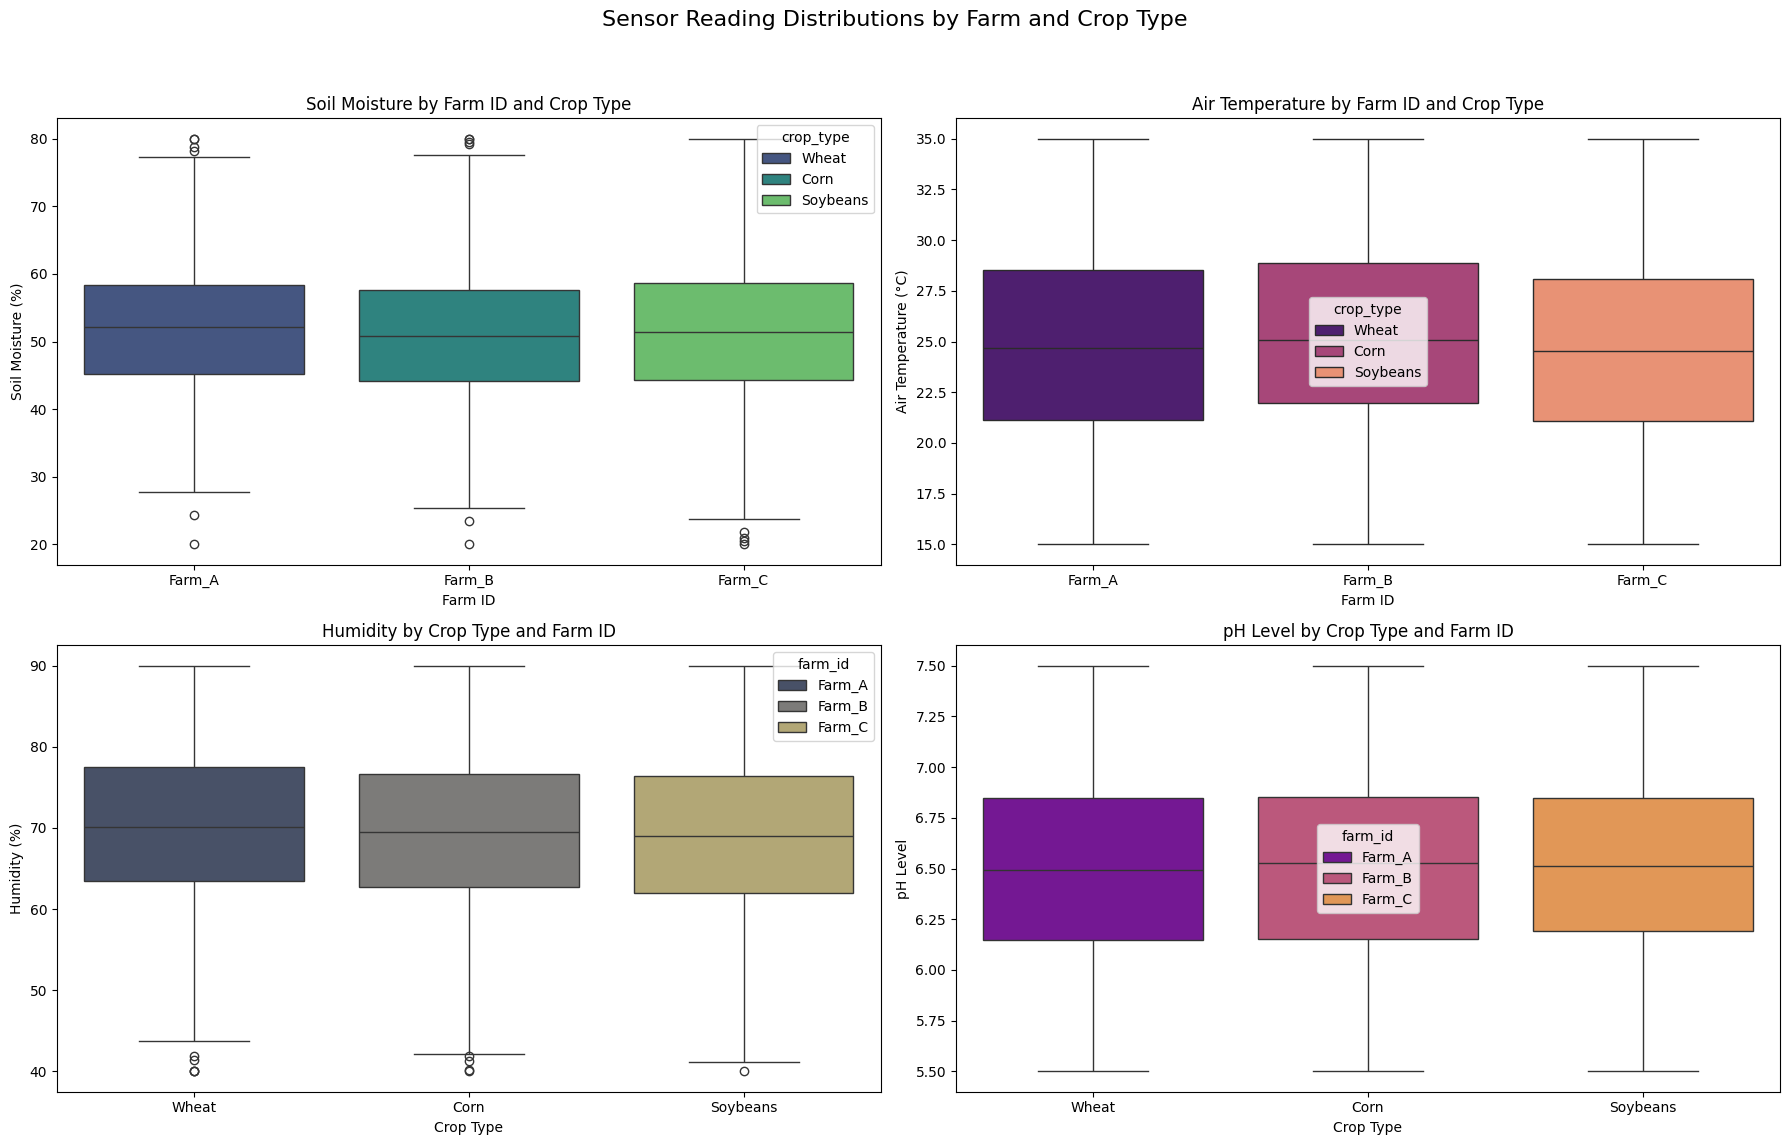

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Sensor Reading Distributions by Farm and Crop Type', fontsize=16)

# Soil Moisture by Farm_ID
sns.boxplot(data=df, x='farm_id', y='soil_moisture', hue='crop_type', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Soil Moisture by Farm ID and Crop Type')
axes[0, 0].set_xlabel('Farm ID')
axes[0, 0].set_ylabel('Soil Moisture (%)')

# Air Temperature by Farm_ID
sns.boxplot(data=df, x='farm_id', y='air_temperature', hue='crop_type', palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Air Temperature by Farm ID and Crop Type')
axes[0, 1].set_xlabel('Farm ID')
axes[0, 1].set_ylabel('Air Temperature (°C)')

# Humidity by Crop_Type
sns.boxplot(data=df, x='crop_type', y='humidity', hue='farm_id', palette='cividis', ax=axes[1, 0])
axes[1, 0].set_title('Humidity by Crop Type and Farm ID')
axes[1, 0].set_xlabel('Crop Type')
axes[1, 0].set_ylabel('Humidity (%)')

# pH Level by Crop_Type
sns.boxplot(data=df, x='crop_type', y='ph_level', hue='farm_id', palette='plasma', ax=axes[1, 1])
axes[1, 1].set_title('pH Level by Crop Type and Farm ID')
axes[1, 1].set_xlabel('Crop Type')
axes[1, 1].set_ylabel('pH Level')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## Correlation Heatmap of Sensor Readings

To understand the relationships between different sensor parameters, a correlation heatmap is very useful. It can highlight which variables move together (positive correlation) or in opposite directions (negative correlation).

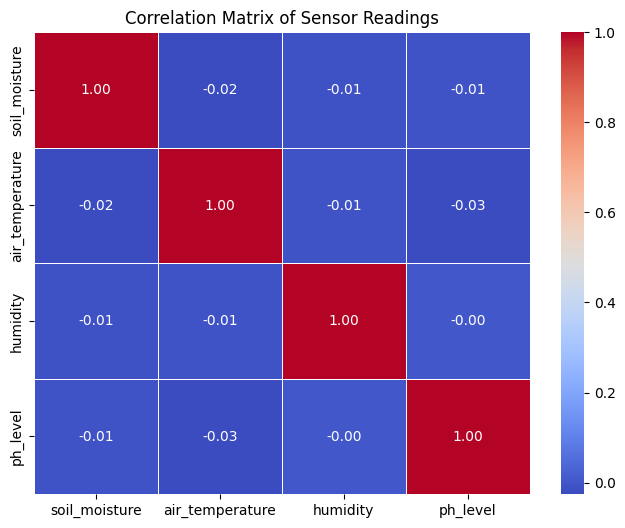

In [7]:
numerical_cols = ['soil_moisture', 'air_temperature', 'humidity', 'ph_level']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Sensor Readings')
plt.show()

## Daily Average Trends for All Sensor Readings

Let's visualize the daily average trends for all sensor readings across the entire dataset. This can help identify broader patterns over the month, such as increasing or decreasing trends, or consistent fluctuations.

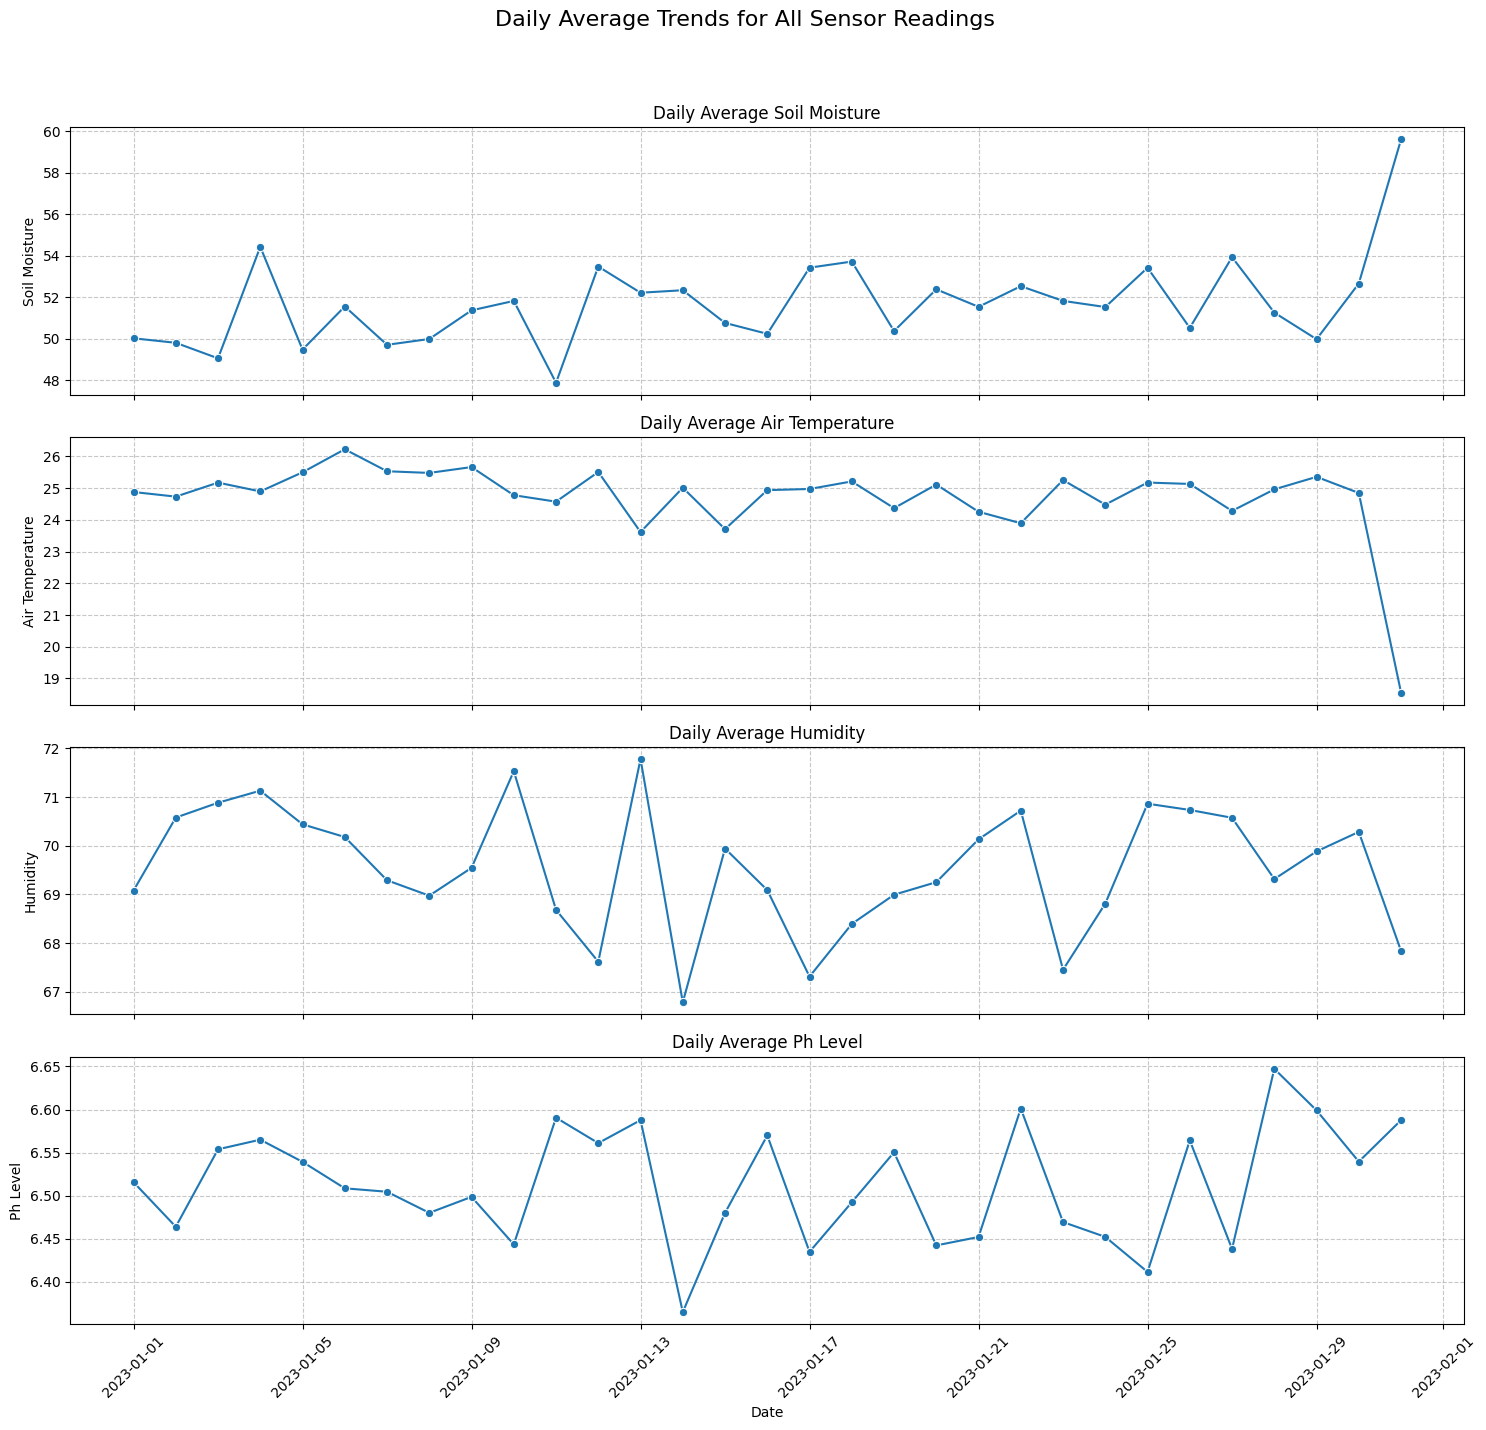

In [8]:
df['date'] = df['timestamp'].dt.date
daily_avg_sensors = df.groupby('date')[numerical_cols].mean().reset_index()

fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(15, 15), sharex=True)
fig.suptitle('Daily Average Trends for All Sensor Readings', fontsize=16)

for i, col in enumerate(numerical_cols):
    sns.lineplot(data=daily_avg_sensors, x='date', y=col, ax=axes[i], marker='o')
    axes[i].set_title(f'Daily Average {col.replace("_", " ").title()}')
    axes[i].set_ylabel(col.replace("_", " ").title())
    axes[i].grid(True, linestyle='--', alpha=0.7)

axes[-1].set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Sensor Metrics Dashboard Layout

Here's a dashboard combining key visualizations for a quick overview of the agricultural IoT sensor data. This layout integrates time-series, distribution, correlation, and daily trend plots into a single view.

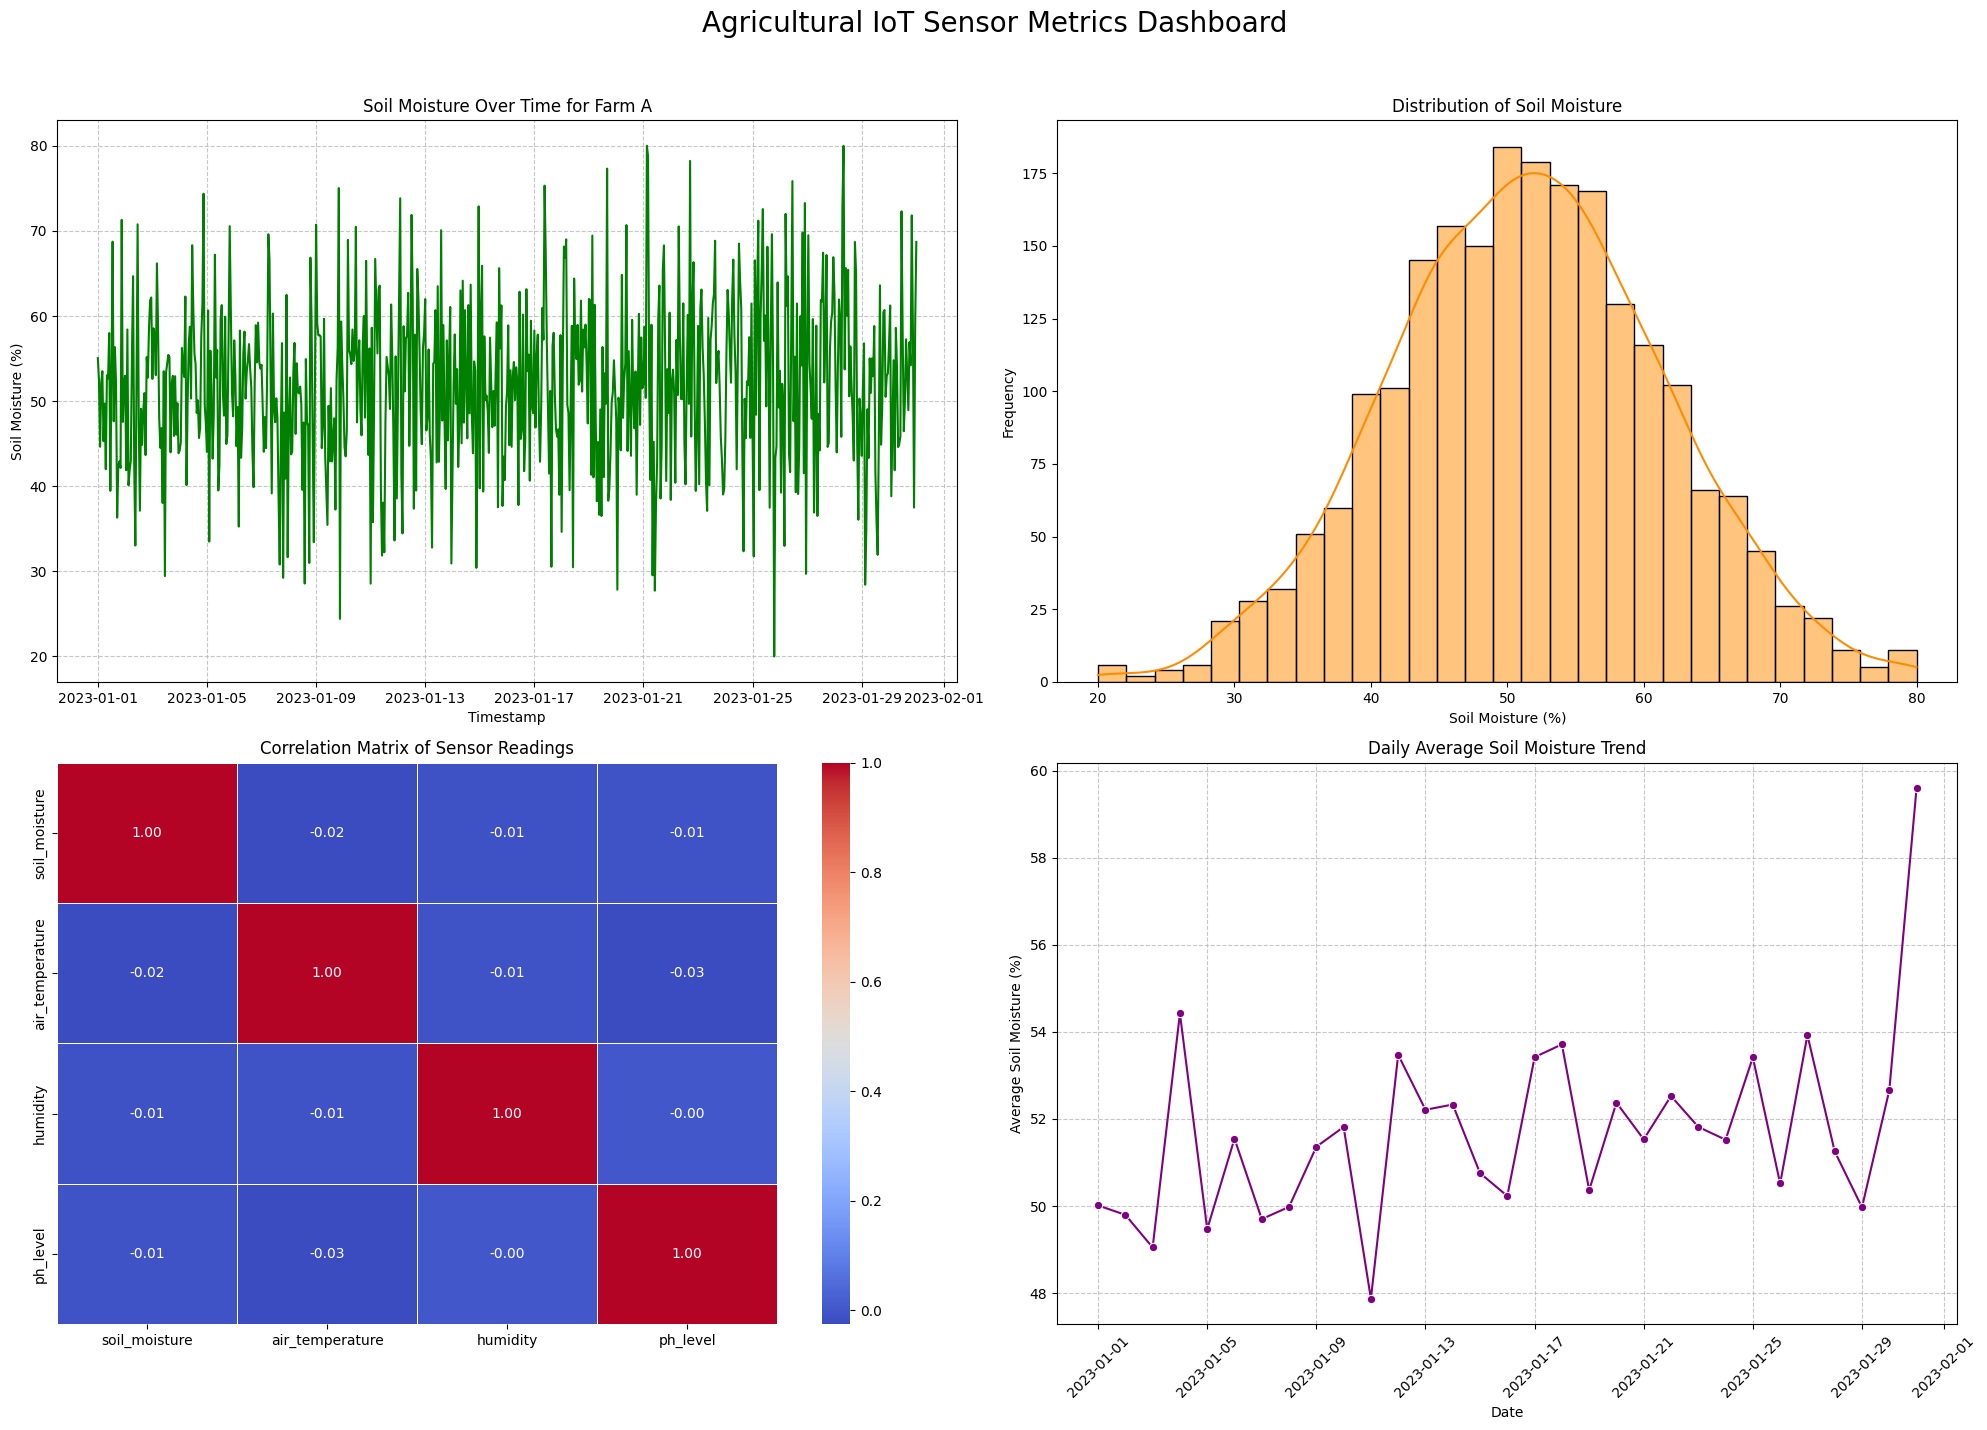

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))
fig.suptitle('Agricultural IoT Sensor Metrics Dashboard', fontsize=20)

# Plot 1: Time-series of Soil Moisture for Farm A (top-left)
# Re-using the time-series plot logic for one sensor
sns.lineplot(data=df[df['farm_id'] == 'Farm_A'], x='timestamp', y='soil_moisture', ax=axes[0, 0], color='green')
axes[0, 0].set_title('Soil Moisture Over Time for Farm A')
axes[0, 0].set_xlabel('Timestamp')
axes[0, 0].set_ylabel('Soil Moisture (%)')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Distribution of Soil Moisture (top-right)
sns.histplot(df['soil_moisture'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Distribution of Soil Moisture')
axes[0, 1].set_xlabel('Soil Moisture (%)')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Correlation Heatmap of Sensor Readings (bottom-left)
numerical_cols = ['soil_moisture', 'air_temperature', 'humidity', 'ph_level']
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix of Sensor Readings')

# Plot 4: Daily Average Trend for Soil Moisture (bottom-right)
df['date'] = df['timestamp'].dt.date
daily_avg_sensors = df.groupby('date')[numerical_cols].mean().reset_index()
sns.lineplot(data=daily_avg_sensors, x='date', y='soil_moisture', ax=axes[1, 1], marker='o', color='purple')
axes[1, 1].set_title('Daily Average Soil Moisture Trend')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Average Soil Moisture (%)')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

## Anomaly Detection using Isolation Forest

Now, let's use an Isolation Forest to detect anomalies in the sensor data. This can help identify unusual patterns or outliers that might require further investigation in a real-world IoT agricultural system.

In [10]:
from sklearn.ensemble import IsolationForest

# Select numerical features for anomaly detection
# We will use the same numerical_cols defined earlier
numerical_cols = ['soil_moisture', 'air_temperature', 'humidity', 'ph_level']
X = df[numerical_cols]

# Initialize and train the Isolation Forest model
# contamination is the proportion of outliers in the data set and is used when fitting the model.
# A common practice is to set it to 'auto' or a small percentage (e.g., 0.01 for 1% outliers).
isolation_forest = IsolationForest(random_state=42, contamination='auto')
isolation_forest.fit(X)

# Predict anomaly scores and labels (-1 for anomalies, 1 for inliers)
df['anomaly_score'] = isolation_forest.decision_function(X)
df['is_anomaly'] = isolation_forest.predict(X)

# Display the head of the DataFrame with new anomaly columns
print("DataFrame with Anomaly Scores and Labels:")
display(df.head())

# Display the count of anomalies
print(f"\nNumber of detected anomalies: {df[df['is_anomaly'] == -1].shape[0]}")

DataFrame with Anomaly Scores and Labels:


,timestamp,farm_id,crop_type,soil_moisture,air_temperature,humidity,ph_level,date,anomaly_score,is_anomaly
0,2023-01-01 00:00:00,Farm_A,Wheat,55.053208,24.308678,81.476885,7.261515,2023-01-01,0.019792,1
1,2023-01-01 00:00:00,Farm_B,Corn,47.744533,23.829315,90.000000,6.883717,2023-01-01,0.012628,1
2,2023-01-01 00:00:00,Farm_C,Soybeans,45.391323,27.712800,70.365823,6.267135,2023-01-01,0.082919,1
3,2023-01-01 01:00:00,Farm_A,Wheat,52.505689,16.210056,57.580451,6.218856,2023-01-01,0.031564,1
4,2023-01-01 01:00:00,Farm_B,Corn,39.957756,27.347694,65.749388,5.793848,2023-01-01,0.036360,1



Number of detected anomalies: 683


## Visualizing Detected Anomalies

To better understand the detected anomalies, let's visualize them. We'll plot the soil moisture over time and mark the points identified as anomalies by the Isolation Forest.

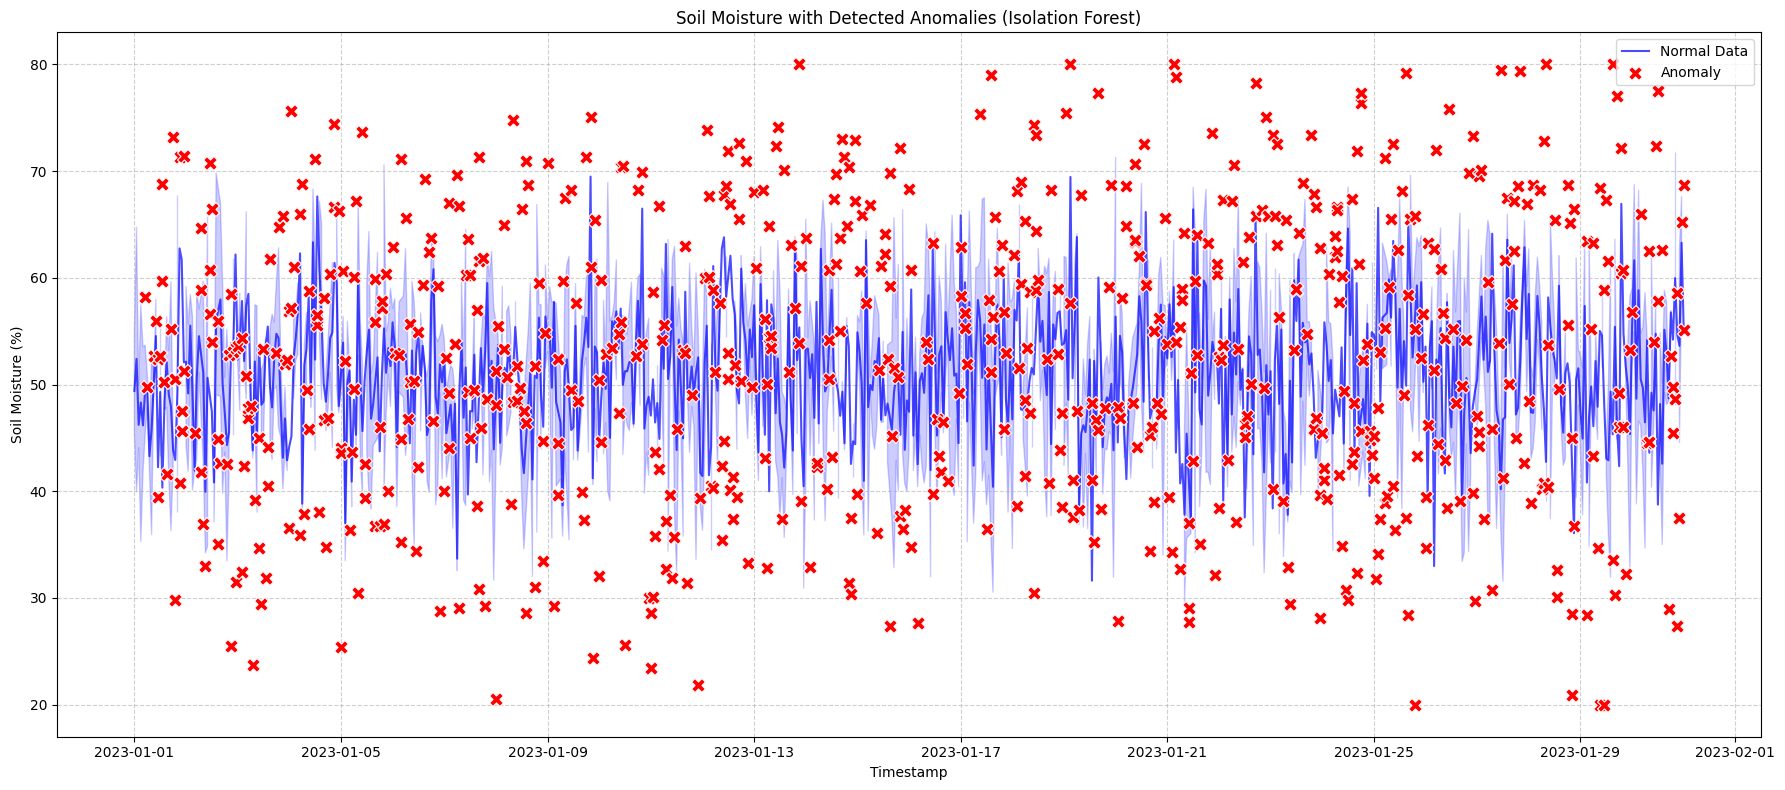

In [11]:
plt.figure(figsize=(18, 8))

# Plot normal data points
sns.lineplot(data=df[df['is_anomaly'] == 1], x='timestamp', y='soil_moisture', label='Normal Data', color='blue', alpha=0.7)

# Plot anomalies as red dots
sns.scatterplot(data=df[df['is_anomaly'] == -1], x='timestamp', y='soil_moisture', label='Anomaly', color='red', s=100, marker='X', zorder=5)

plt.title('Soil Moisture with Detected Anomalies (Isolation Forest)')
plt.xlabel('Timestamp')
plt.ylabel('Soil Moisture (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

This visualization helps in quickly spotting when and where the anomalies occurred in the soil moisture readings. Similar visualizations could be created for other sensor metrics or combined into an extended dashboard for a comprehensive anomaly overview.

## Comprehensive 15-Insight Sensor Metrics Dashboard

This dashboard presents a wider array of visualizations, combining daily averages, distributions, inter-farm/inter-crop comparisons, and relationships between sensor readings to offer a comprehensive understanding of the agricultural IoT data.

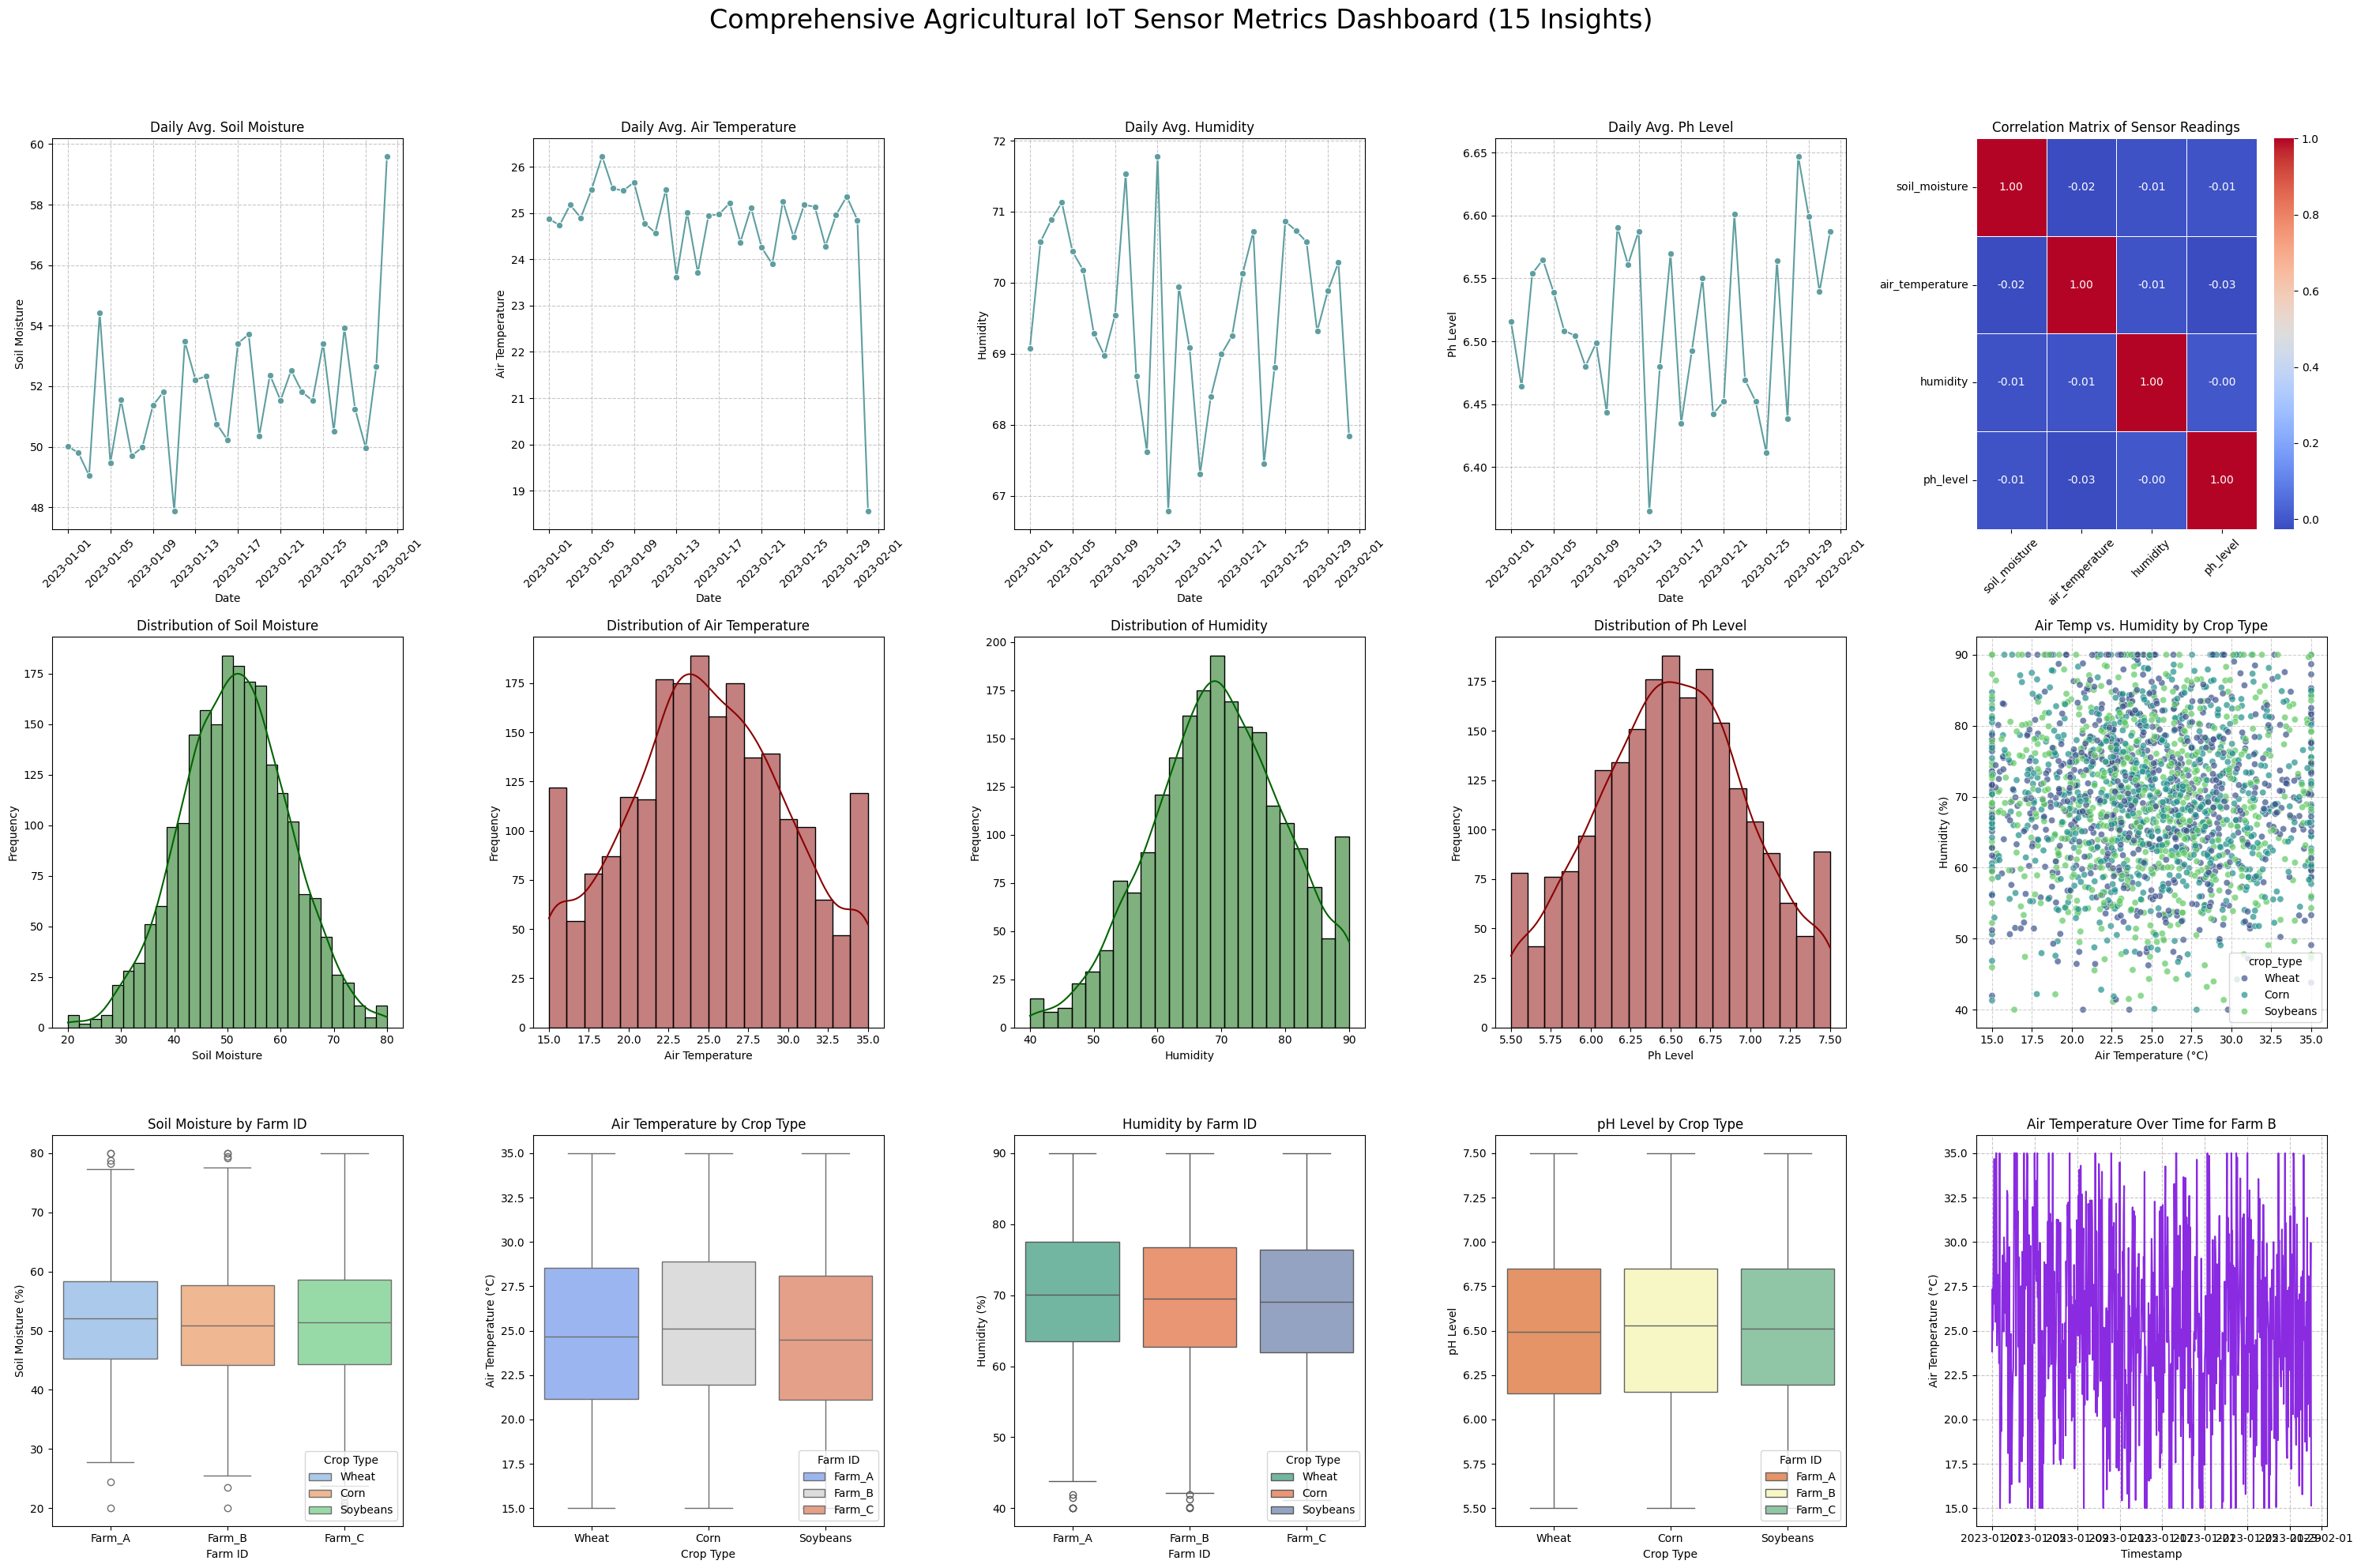

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(30, 20))
fig.suptitle('Comprehensive Agricultural IoT Sensor Metrics Dashboard (15 Insights)', fontsize=24, y=1.02)

numerical_cols = ['soil_moisture', 'air_temperature', 'humidity', 'ph_level']

# Prepare daily averages (used for several plots)
df_copy = df.copy()
df_copy['date'] = df_copy['timestamp'].dt.date
daily_avg_sensors = df_copy.groupby('date')[numerical_cols].mean().reset_index()

# --- Row 1: Overall Daily Average Trends for each Sensor ---
for i, col in enumerate(numerical_cols):
    sns.lineplot(data=daily_avg_sensors, x='date', y=col, ax=axes[0, i], marker='o', color='cadetblue')
    axes[0, i].set_title(f'Daily Avg. {col.replace("_", " ").title()}')
    axes[0, i].set_xlabel('Date')
    axes[0, i].set_ylabel(col.replace("_", " ").title())
    axes[0, i].grid(True, linestyle='--', alpha=0.7)
    axes[0, i].tick_params(axis='x', rotation=45)

# Plot 5: Correlation Heatmap (using numerical_cols)
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[0, 4])
axes[0, 4].set_title('Correlation Matrix of Sensor Readings')
axes[0, 4].tick_params(axis='x', rotation=45)
axes[0, 4].tick_params(axis='y', rotation=0)

# --- Row 2: Distributions for each Sensor ---
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[1, i], color='darkgreen' if i%2==0 else 'darkred')
    axes[1, i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[1, i].set_xlabel(col.replace("_", " ").title())
    axes[1, i].set_ylabel('Frequency')

# Plot 10: Scatter Plot: Air Temperature vs. Humidity
sns.scatterplot(data=df, x='air_temperature', y='humidity', hue='crop_type', palette='viridis', alpha=0.7, ax=axes[1, 4])
axes[1, 4].set_title('Air Temp vs. Humidity by Crop Type')
axes[1, 4].set_xlabel('Air Temperature (°C)')
axes[1, 4].set_ylabel('Humidity (%)')
axes[1, 4].grid(True, linestyle='--', alpha=0.6)

# --- Row 3: Comparisons by Farm / Crop Type & Specific Time Series ---
# Plot 11: Boxplot: Soil Moisture by Farm ID
sns.boxplot(data=df, x='farm_id', y='soil_moisture', hue='crop_type', palette='pastel', ax=axes[2, 0])
axes[2, 0].set_title('Soil Moisture by Farm ID')
axes[2, 0].set_xlabel('Farm ID')
axes[2, 0].set_ylabel('Soil Moisture (%)')
axes[2, 0].legend(title='Crop Type', loc='lower right')

# Plot 12: Boxplot: Air Temperature by Crop Type
sns.boxplot(data=df, x='crop_type', y='air_temperature', hue='farm_id', palette='coolwarm', ax=axes[2, 1])
axes[2, 1].set_title('Air Temperature by Crop Type')
axes[2, 1].set_xlabel('Crop Type')
axes[2, 1].set_ylabel('Air Temperature (°C)')
axes[2, 1].legend(title='Farm ID', loc='lower right')

# Plot 13: Boxplot: Humidity by Farm ID
sns.boxplot(data=df, x='farm_id', y='humidity', hue='crop_type', palette='Set2', ax=axes[2, 2])
axes[2, 2].set_title('Humidity by Farm ID')
axes[2, 2].set_xlabel('Farm ID')
axes[2, 2].set_ylabel('Humidity (%)')
axes[2, 2].legend(title='Crop Type', loc='lower right')

# Plot 14: Boxplot: pH Level by Crop Type
sns.boxplot(data=df, x='crop_type', y='ph_level', hue='farm_id', palette='Spectral', ax=axes[2, 3])
axes[2, 3].set_title('pH Level by Crop Type')
axes[2, 3].set_xlabel('Crop Type')
axes[2, 3].set_ylabel('pH Level')
axes[2, 3].legend(title='Farm ID', loc='lower right')

# Plot 15: Time-series of Air Temperature for Farm B (hourly)
sns.lineplot(data=df[df['farm_id'] == 'Farm_B'], x='timestamp', y='air_temperature', ax=axes[2, 4], color='blueviolet')
axes[2, 4].set_title('Air Temperature Over Time for Farm B')
axes[2, 4].set_xlabel('Timestamp')
axes[2, 4].set_ylabel('Air Temperature (°C)')
axes[2, 4].grid(True, linestyle='--', alpha=0.7)


plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout for suptitle
plt.show()

## Comparing Anomalies Across Crop Types

To understand how anomalies manifest in different agricultural settings, let's compare the distributions of the detected anomalous sensor readings across each crop type.

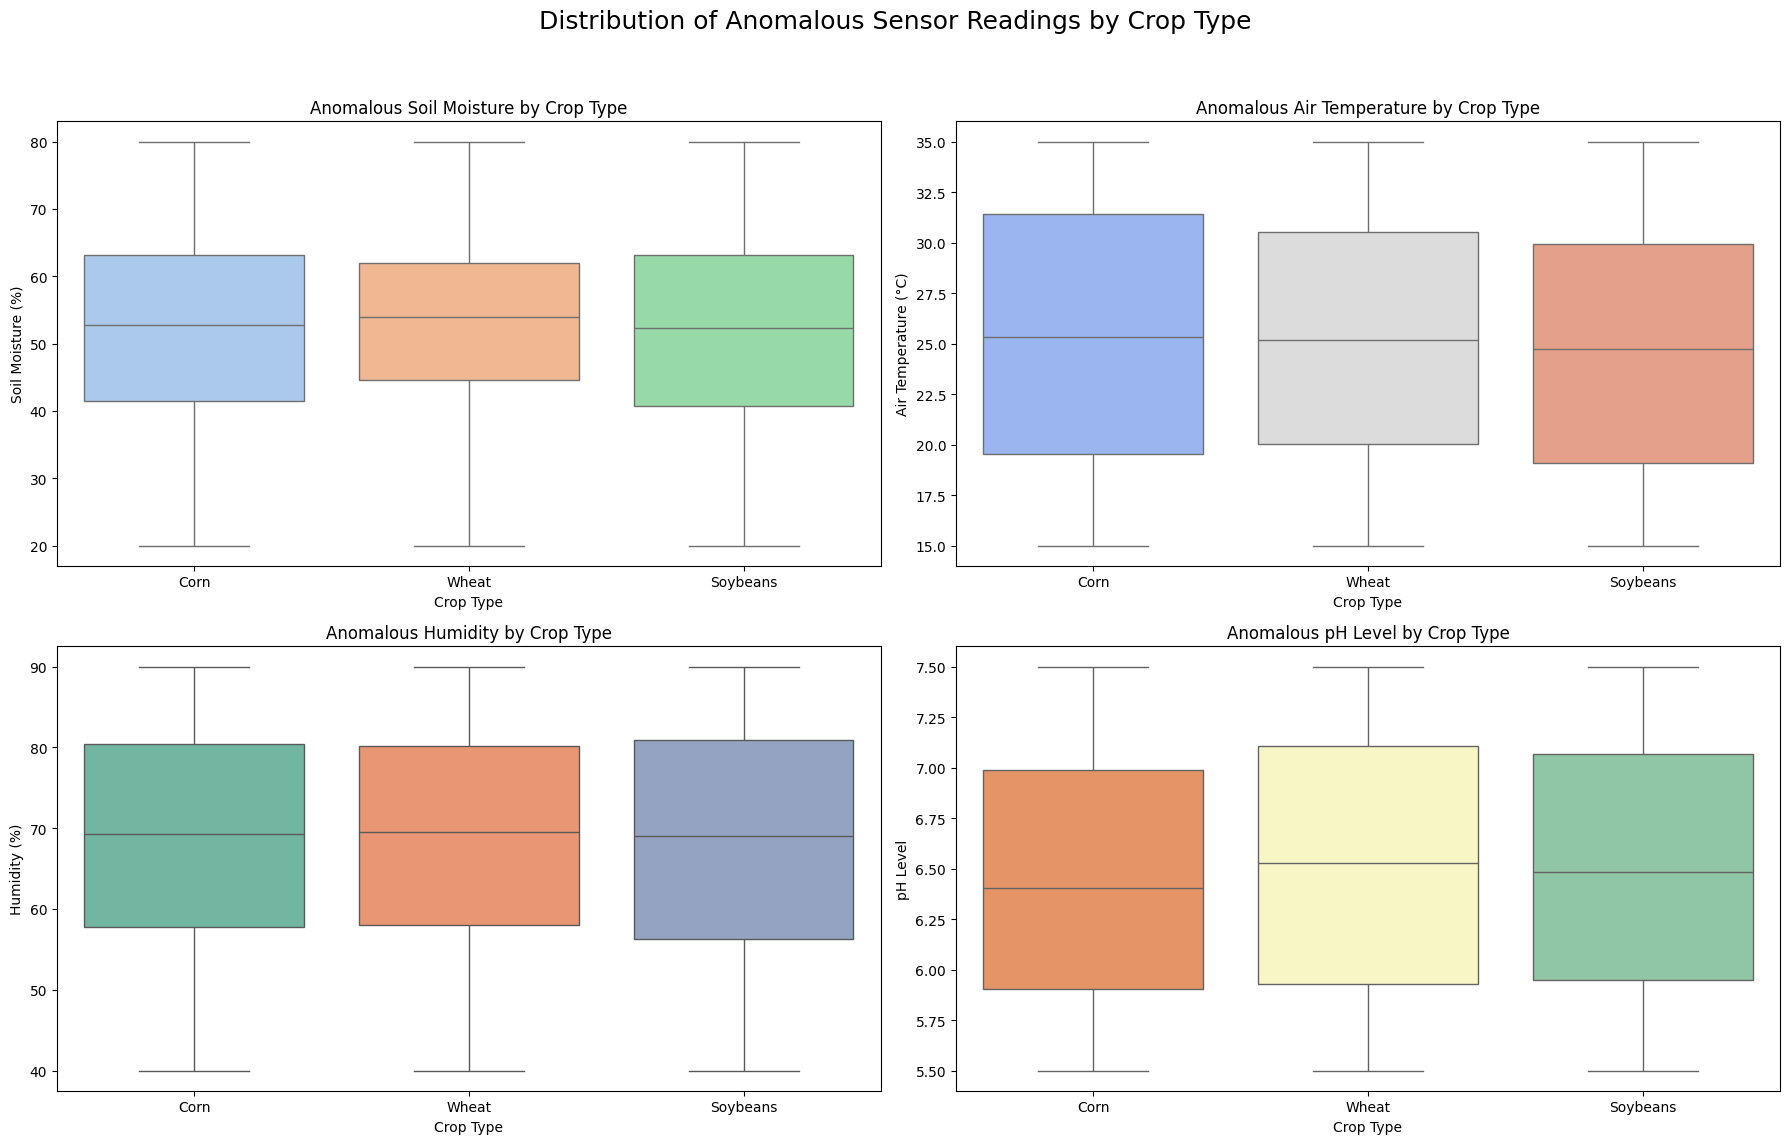

In [14]:
anomalies_df = df[df['is_anomaly'] == -1]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distribution of Anomalous Sensor Readings by Crop Type', fontsize=18)

# Box plot for anomalous Soil Moisture by Crop Type
sns.boxplot(data=anomalies_df, x='crop_type', y='soil_moisture', hue='crop_type', palette='pastel', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Anomalous Soil Moisture by Crop Type')
axes[0, 0].set_xlabel('Crop Type')
axes[0, 0].set_ylabel('Soil Moisture (%)')

# Box plot for anomalous Air Temperature by Crop Type
sns.boxplot(data=anomalies_df, x='crop_type', y='air_temperature', hue='crop_type', palette='coolwarm', ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Anomalous Air Temperature by Crop Type')
axes[0, 1].set_xlabel('Crop Type')
axes[0, 1].set_ylabel('Air Temperature (°C)')

# Box plot for anomalous Humidity by Crop Type
sns.boxplot(data=anomalies_df, x='crop_type', y='humidity', hue='crop_type', palette='Set2', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Anomalous Humidity by Crop Type')
axes[1, 0].set_xlabel('Crop Type')
axes[1, 0].set_ylabel('Humidity (%)')

# Box plot for anomalous pH Level by Crop Type
sns.boxplot(data=anomalies_df, x='crop_type', y='ph_level', hue='crop_type', palette='Spectral', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Anomalous pH Level by Crop Type')
axes[1, 1].set_xlabel('Crop Type')
axes[1, 1].set_ylabel('pH Level')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Top Farms with Anomalies

Identifying which farms experience a higher frequency of anomalies can point to specific issues or environmental factors at those locations.

In [15]:
# Group by farm_id and count the number of anomalies
anomaly_counts_by_farm = anomalies_df['farm_id'].value_counts().reset_index()
anomaly_counts_by_farm.columns = ['farm_id', 'anomaly_count']

# Sort in descending order and get the top 3
top_3_farms_anomalies = anomaly_counts_by_farm.head(3)

print("Top 3 Farms with the Highest Number of Anomalies:")
display(top_3_farms_anomalies)

Top 3 Farms with the Highest Number of Anomalies:


,farm_id,anomaly_count
0,Farm_C,241
1,Farm_B,228
2,Farm_A,214


/tmp/ipykernel_857/1944581790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='farm_id', y='anomaly_count', data=top_3_farms_anomalies, palette='viridis')


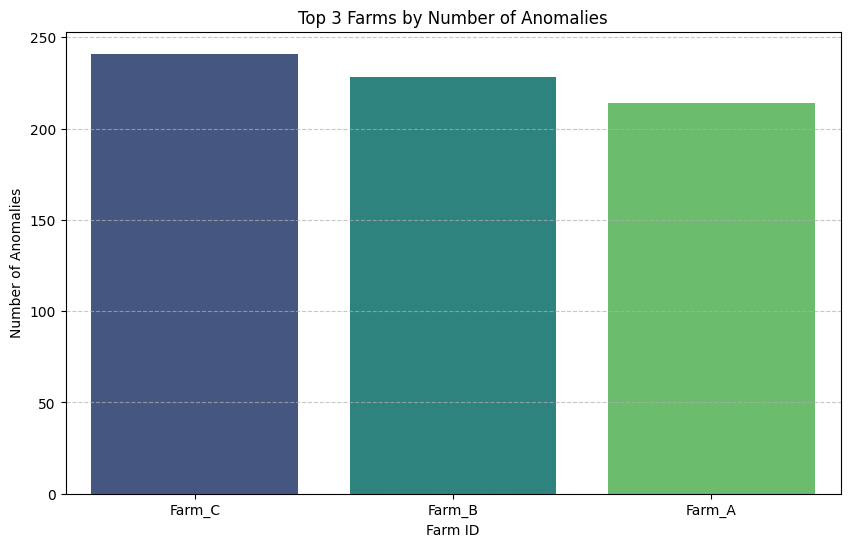

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x='farm_id', y='anomaly_count', data=top_3_farms_anomalies, hue='farm_id', palette='viridis', legend=False)
plt.title('Top 3 Farms by Number of Anomalies')
plt.xlabel('Farm ID')
plt.ylabel('Number of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()